# Scenario weights for grid expansion delays

1. Build the empirical delay distribution $P(D > t)$ from the two NEP monitoring histograms (realized + expected delays, pooled).
2. Read the planned transmission projects and compute their capacity in TWkm.
3. Define six grid scenarios (2025, 2027, ..., 2035 grid) and their total capacities.
4. Monte Carlo: draw a delay per project, see what stands in 2035, assign to the nearest scenario capacity.
5. Scenario frequencies = scenario weights for the stochastic LP.

---

## Context for whoever picks this up next

### What this is for

A **proof-of-concept paper**. A stochastic LP (PyPSA) is planned with **six scenarios** that differ only in
the transmission grid. The six grids are nested: the "year-$y$ grid" contains every NEP project planned
for completion up to $y$, for $y \in \{2025, 2027, \dots, 2035\}$. The LP needs one probability weight per
scenario, summing to 1. **Producing those six weights is the entire job of this notebook.**

Everything is deliberately kept simple — the point of the paper is that grid-delay risk *can* be
quantified from public monitoring data, not that this particular estimator is the best possible one.

### Data sources

| Input | Origin | Note |
|---|---|---|
| `realized_counts` | NEP monitoring histogram, 34 completed projects | read off the bar chart by eye |
| `expected_counts` | NEP monitoring histogram, 71 ongoing projects | read off the bar chart by eye |
| `new_links.csv` | NEP DC projects | `p_nom` [MW], `length` [km], `build_year` |
| `new_lines.csv` | NEP AC projects | `num_parallel`, `length` [km], `build_year`, 380 kV HTLS |

The two histograms are **pooled and treated identically** — a realized delay of a finished project and an
expected delay of an ongoing one both count as one observation. $n = 105$, mean 2.94 a, median 2 a.
Delays are drawn from this pooled sample by bootstrap, so no distributional assumption is made.

### The model in one paragraph

Draw a delay for every project not yet built as of 2025. Add it to the planned year. A project is in the
2035 grid iff `build_year + delay <= 2035` — so a project planned for 2027 may slip 8 years and still make
it, one planned for 2035 may not slip at all. Sum the capacities of the projects that make it; this gives
one realized capacity per draw. Assign that realization to whichever of the six scenario grids has the
closest total capacity (bin edges at the midpoints). Repeat 100 000 times; the bin frequencies are the
scenario weights. They sum to 1 by construction, with no renormalisation.

### Design decisions that were settled — do not silently revisit

- **Project-weighted, not capacity-weighted empirical distribution.** $\hat P(D>t) = \frac{1}{N}\sum_i
  \mathbf{1}(D_i > t)$. Weighting the *historical* projects by capacity would double-count capacity,
  since capacity already enters through the $C_j$ of the *future* projects.
- **Capacity matching, not a median-delay threshold.** An earlier formulation asked for "at least half of
  the capacity delayed by more than $t$ years". It was dropped because (a) the relevant project set would
  change between scenarios, so the events are neither nested nor disjoint and the weights do not sum to 1,
  and (b) it ignores the buffer to 2035 — a 2027 project with 2 years delay is still there in 2035.
- **`>` vs `≥` is a non-issue.** The only comparison in the model is the arrival condition
  `build_year + delay <= 2035`, which is unambiguous. $P(D>t)$ appears only as a descriptive table; for
  integer delays $P(D \ge t) = P(D > t-1)$, so relabelling changes no number. Sanity check: a uniform
  2-year slip across all projects reproduces $\mathrm{Cap}_{2033}$ exactly and lands in the 2033 bin.
- **Delay probability assumed independent of project size**, i.e. $P(D>t \mid C) = P(D>t)$. A size-dependent
  variant was considered and rejected for the PoC: with ~5 delayed projects at large $t$, the size effect
  is not estimable. If a reviewer pushes, a median split of the historical projects by capacity is a cheap
  robustness check for $t = 2, 4$ only.
- **Monte Carlo is the primary method**, the exact convolution in the last section is only a cross-check.
  At 100 000 draws the weights are accurate to ±0.002, far finer than the uncertainty in the underlying
  delay distribution from 105 observations. The two agree to four decimals.

### Parameters and switches

- `S_NOM_PER_CIRCUIT = 1700 MW` — **the weakest input.** AC line capacity is `num_parallel × S_NOM × length`.
  Changing it rescales AC capacity relative to DC and therefore shifts the bin edges. Worth a sensitivity run.
- `BASE_YEAR = 2025` — projects with `build_year <= 2025` are treated as part of the base grid and get no
  random delay. The CSVs do not record actual completion status, so this is an assumption; a few entries
  with `build_year` 2023–2025 are still flagged `in_permitting`.
- Projects with `build_year > 2035` (14 of them, 8.9 TWkm) are **excluded** — they cannot contribute to a
  2035 grid and the model has no mechanism for early completion.
- `SEED = 0`, `N_DRAWS = 100_000`.

### Current result

Weights ≈ 2025: 0.000 | 2027: 0.000 | 2029: 0.052 | 2031: 0.514 | 2033: 0.423 | 2035: 0.011.

Two things to be aware of when interpreting: the on-time scenario gets only ~1 %, driven by
$P(D>0) = 0.66$ (two thirds of historical projects slipped at all); and almost all mass sits on the
2031/2033 grids, i.e. a 2–4 year programme slip.

### Known limitations (belong in the paper)

1. **Independence across projects.** The strongest assumption. Real delays are correlated through shared
   permitting law, supply chains and legal environment, which would fatten the tails and make the extreme
   scenarios more likely than computed here. Free reference points if needed: under perfect correlation the
   stage probability collapses to the single-project probability.
2. **Topology is ignored.** A realization is matched to a scenario grid by *total* TWkm only. Two grids with
   the same total but different corridors are not distinguished.
3. **Histogram counts were read off plots by eye** and should be replaced by the underlying NEP table if it
   can be obtained.
4. The pooled sample mixes *realized* and *expected* delays; expected delays of ongoing projects may still
   grow, so the distribution is arguably optimistic.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE_YEAR = 2025
HORIZON = 2035
SCENARIO_YEARS = [2025, 2027, 2029, 2031, 2033, 2035]
N_DRAWS = 100_000
SEED = 0

# HTLS 4-bundle 380 kV, thermal rating per circuit [MW]
S_NOM_PER_CIRCUIT = 1700.0

data_dir = Path("/home/mlindner/git/pypsa-local")
rng = np.random.default_rng(SEED)

## 1. Empirical delay distribution

Both monitoring histograms are pooled: realized delays of completed projects and expected delays of
projects still under way are treated identically. Counts are read off the two bar charts.

In [2]:
# delay in years -> number of projects
realized_counts = {0: 12, 1: 5, 2: 7, 3: 2, 4: 2, 5: 1, 6: 3, 7: 0, 8: 1, 9: 1}
expected_counts = {
    0: 24, 1: 8, 2: 8, 3: 6, 4: 4, 5: 5, 6: 3, 7: 1,
    8: 1, 9: 3, 10: 2, 11: 2, 12: 2, 13: 1, 14: 1,
}

counts = pd.Series(realized_counts, name="realized").add(
    pd.Series(expected_counts, name="expected"), fill_value=0
).astype(int)
counts.index.name = "delay"

delay_sample = np.repeat(counts.index.to_numpy(), counts.to_numpy())
n_historical = delay_sample.size

print(f"n = {n_historical} projects (34 completed + 71 ongoing)")
print(f"mean {delay_sample.mean():.2f} a, median {np.median(delay_sample):.1f} a")

n = 105 projects (34 completed + 71 ongoing)
mean 2.94 a, median 2.0 a


In [3]:
thresholds = np.arange(0, 15)
survival = pd.Series(
    [(delay_sample > t).mean() for t in thresholds], index=thresholds, name="P(D > t)"
)
survival.index.name = "t [a]"
survival.round(3).to_frame()

,P(D > t)
t [a],
0,0.657
1,0.533
2,0.390
3,0.314
4,0.257
5,0.200
6,0.143
7,0.133
8,0.114


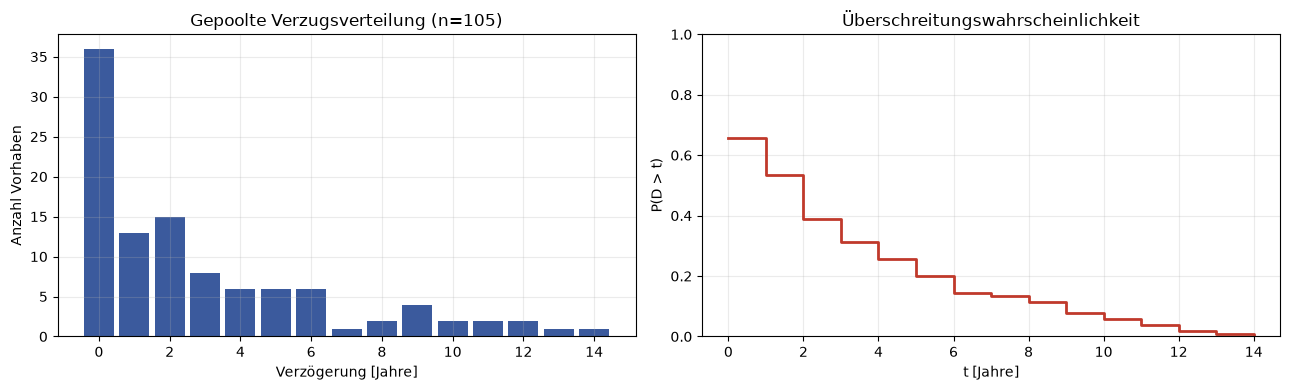

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(counts.index, counts.to_numpy(), color="#3b5a9d", width=0.85)
axes[0].set_xlabel("Verzögerung [Jahre]")
axes[0].set_ylabel("Anzahl Vorhaben")
axes[0].set_title(f"Gepoolte Verzugsverteilung (n={n_historical})")

axes[1].step(survival.index, survival.to_numpy(), where="post", color="#c0392b", lw=2)
axes[1].set_xlabel("t [Jahre]")
axes[1].set_ylabel("P(D > t)")
axes[1].set_ylim(0, 1)
axes[1].set_title("Überschreitungswahrscheinlichkeit")

for axis in axes:
    axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 2. Transmission projects and their capacity

Capacity in TWkm: DC links use `p_nom * length`, AC lines use `num_parallel * S_NOM_PER_CIRCUIT * length`.

In [5]:
links = pd.read_csv(data_dir / "new_links.csv", index_col=0)
lines = pd.read_csv(data_dir / "new_lines.csv", index_col=0)

links_cap = pd.DataFrame(
    {
        "build_year": links["build_year"].astype(int),
        "twkm": links["p_nom"] * links["length"] / 1e6,
        "kind": "DC",
    }
)
lines_cap = pd.DataFrame(
    {
        "build_year": lines["build_year"].astype(int),
        "twkm": lines["num_parallel"] * S_NOM_PER_CIRCUIT * lines["length"] / 1e6,
        "kind": "AC",
    }
)

projects = pd.concat([links_cap, lines_cap])
projects.index.name = "project"

print(f"{len(projects)} projects, {projects.twkm.sum():.1f} TWkm total")
projects.groupby(["kind", "build_year"]).twkm.agg(["count", "sum"]).round(2)

50 projects, 26.6 TWkm total


count   sum
kind build_year             
AC   2023            1  0.21
     2024            4  1.07
     2025            3  1.21
     2026            3  0.63
     2027            3  0.86
     2028            3  1.51
     2029            1  0.41
     2030            1  0.18
     2031            2  0.41
     2032            1  0.13
     2033            1  0.30
     2035            1  0.31
     2037            9  3.11
DC   2026            1  0.60
     2027            2  1.67
     2028            2  2.47
     2030            1  1.52
     2032            3  1.84
     2033            1  1.05
     2034            1  0.34
     2035            1  0.92
     2037            5  5.82

In [6]:
baseline = projects[projects.build_year <= BASE_YEAR]
stochastic = projects[
    (projects.build_year > BASE_YEAR) & (projects.build_year <= HORIZON)
].copy()
beyond = projects[projects.build_year > HORIZON]

cap_base = baseline.twkm.sum()

print(f"baseline (planned <= {BASE_YEAR}): {len(baseline):3d} projects, {cap_base:6.1f} TWkm")
print(f"stochastic ({BASE_YEAR+1}-{HORIZON}):  {len(stochastic):3d} projects, {stochastic.twkm.sum():6.1f} TWkm")
print(f"beyond {HORIZON} (excluded):    {len(beyond):3d} projects, {beyond.twkm.sum():6.1f} TWkm")

baseline (planned <= 2025):   8 projects,    2.5 TWkm
stochastic (2026-2035):   28 projects,   15.2 TWkm
beyond 2035 (excluded):     14 projects,    8.9 TWkm


## 3. Scenario capacities

The "year-$y$ grid" contains all projects planned for completion up to $y$.

In [7]:
scenario_cap = pd.Series(
    {year: projects.loc[projects.build_year <= year, "twkm"].sum() for year in SCENARIO_YEARS},
    name="Cap [TWkm]",
)
scenario_cap.index.name = "grid year"
scenario_cap.round(2).to_frame()

,Cap [TWkm]
grid year,
2025,2.49
2027,6.25
2029,10.64
2031,12.74
2033,16.07
2035,17.64


In [8]:
caps = scenario_cap.to_numpy()
# bin edges halfway between neighbouring scenario capacities, outer edges open
edges = np.concatenate([[-np.inf], (caps[:-1] + caps[1:]) / 2, [np.inf]])

pd.DataFrame(
    {"lower": edges[:-1], "Cap": caps, "upper": edges[1:]}, index=scenario_cap.index
).round(2)

,lower,Cap,upper
grid year,,,
2025,-inf,2.49,4.37
2027,4.37,6.25,8.45
2029,8.45,10.64,11.69
2031,11.69,12.74,14.41
2033,14.41,16.07,16.86
2035,16.86,17.64,inf


## 4. Monte Carlo

One experiment: draw one of the historical delays for every stochastic project, add it to its planned
year, keep the projects that finish by 2035, sum their capacity, assign the result to a bin.
Draws are independent across projects.

In [9]:
build_year = stochastic.build_year.to_numpy()
twkm = stochastic.twkm.to_numpy()

delays = rng.choice(delay_sample, size=(N_DRAWS, build_year.size))
available = (build_year + delays) <= HORIZON
realized_cap = cap_base + available @ twkm

assigned = np.digitize(realized_cap, edges[1:-1])
weights = pd.Series(
    np.bincount(assigned, minlength=len(SCENARIO_YEARS)) / N_DRAWS,
    index=scenario_cap.index,
    name="probability",
)

result = pd.concat([scenario_cap.round(2), weights.round(4)], axis=1)
result["delay [a]"] = HORIZON - result.index
print(f"sum of weights: {weights.sum():.4f}")
result

sum of weights: 1.0000


,Cap [TWkm],probability,delay [a]
grid year,,,
2025,2.49,0.0000,10
2027,6.25,0.0002,8
2029,10.64,0.0516,6
2031,12.74,0.5144,4
2033,16.07,0.4231,2
2035,17.64,0.0107,0


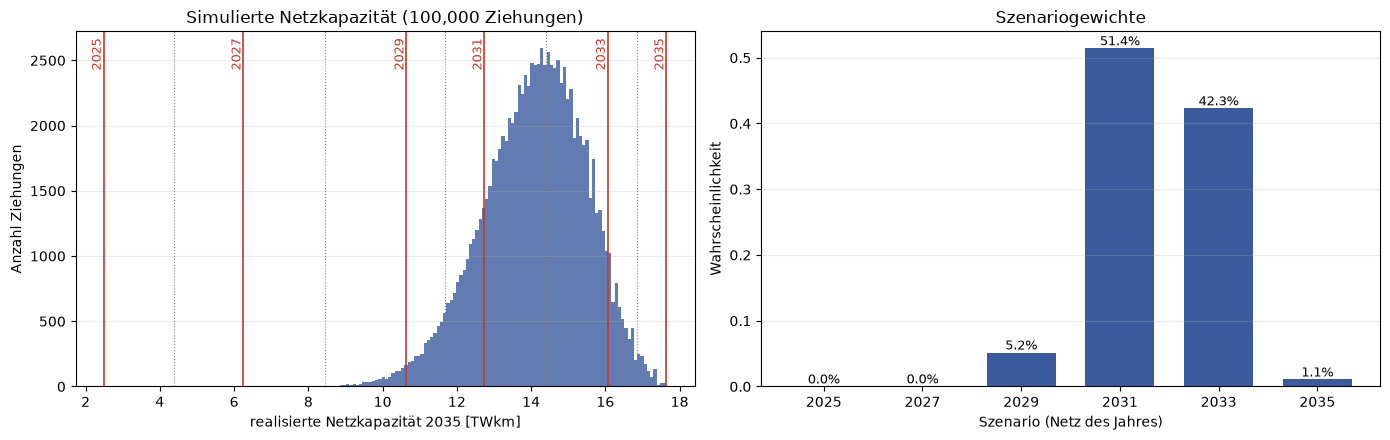

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(realized_cap, bins=120, color="#3b5a9d", alpha=0.8)
for year, cap in scenario_cap.items():
    axes[0].axvline(cap, color="#c0392b", lw=1.2)
    axes[0].text(cap, axes[0].get_ylim()[1] * 0.98, str(year), rotation=90,
                 ha="right", va="top", color="#c0392b", fontsize=9)
for edge in edges[1:-1]:
    axes[0].axvline(edge, color="grey", lw=0.8, ls=":")
axes[0].set_xlabel("realisierte Netzkapazität 2035 [TWkm]")
axes[0].set_ylabel("Anzahl Ziehungen")
axes[0].set_title(f"Simulierte Netzkapazität ({N_DRAWS:,} Ziehungen)")

axes[1].bar([str(y) for y in weights.index], weights.to_numpy(), color="#3b5a9d", width=0.7)
for position, value in enumerate(weights.to_numpy()):
    axes[1].text(position, value, f"{value:.1%}", ha="center", va="bottom", fontsize=9)
axes[1].set_xlabel("Szenario (Netz des Jahres)")
axes[1].set_ylabel("Wahrscheinlichkeit")
axes[1].set_title("Szenariogewichte")

for axis in axes:
    axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## 5. Exact cross-check

Since the projects are independent, the distribution of the realized capacity can also be convolved
exactly. This only verifies the Monte Carlo — it is not needed for the result.

In [11]:
resolution = 1e-3  # TWkm grid

p_available = np.array([(delay_sample <= HORIZON - year).mean() for year in build_year])
grid_cap = np.rint(twkm / resolution).astype(int)

pmf = np.zeros(grid_cap.sum() + 1)
pmf[0] = 1.0
for cap_step, probability in zip(grid_cap, p_available):
    shifted = np.zeros_like(pmf)
    shifted[cap_step:] = pmf[: pmf.size - cap_step]
    pmf = (1 - probability) * pmf + probability * shifted

support = cap_base + np.arange(pmf.size) * resolution
exact = pd.Series(
    np.bincount(np.digitize(support, edges[1:-1]), weights=pmf, minlength=len(SCENARIO_YEARS)),
    index=scenario_cap.index,
    name="exact",
)

pd.concat([weights.rename("monte carlo"), exact], axis=1).round(4)

,monte carlo,exact
grid year,,
2025,0.0000,0.0000
2027,0.0002,0.0002
2029,0.0516,0.0516
2031,0.5144,0.5140
2033,0.4231,0.4235
2035,0.0107,0.0107


In [12]:
result.to_csv(data_dir / "grid_delay_scenario_weights.csv")
result

,Cap [TWkm],probability,delay [a]
grid year,,,
2025,2.49,0.0000,10
2027,6.25,0.0002,8
2029,10.64,0.0516,6
2031,12.74,0.5144,4
2033,16.07,0.4231,2
2035,17.64,0.0107,0


## Assumptions

- Delays are drawn independently per project. In reality they are correlated (shared permitting
  regime, supply chains), which would make the extreme scenarios more likely than computed here.
- The delay distribution does not depend on project size.
- Projects planned before 2026 are treated as part of the base grid; projects planned after 2035 are
  excluded since they cannot contribute to the 2035 grid.
- Scenarios are matched on total capacity, not on topology: a realization is represented by the
  scenario grid with the most similar total TWkm.
- AC line capacity uses a single thermal rating per circuit (`S_NOM_PER_CIRCUIT`).